# Ml Clustering
In this notebook, we will try to find groups for the customers that were not assinged to any group in 3_user_segmentation.ipynb.

In [1]:
import pandas as pd

In [3]:
users_features = pd.read_csv('data/users_no_group.csv')
users_features_all = pd.read_csv('data/user_features.csv')

# Preprocessing

### Gender

In [4]:
users_features['gender'].value_counts()

gender
F    4482
M     576
O       8
Name: count, dtype: int64

In [5]:
users_features['gender'] = users_features['gender'].map({"F":0, "M":1, "O":2})

## Home country

In [6]:
users_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5066 entries, 0 to 5065
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5066 non-null   int64  
 1   gender                     5066 non-null   int64  
 2   married                    5066 non-null   bool   
 3   has_children               5066 non-null   bool   
 4   home_country               5066 non-null   str    
 5   tenure                     5066 non-null   int64  
 6   age                        5066 non-null   int64  
 7   seats_avg                  4525 non-null   float64
 8   checked_bags_avg           4525 non-null   float64
 9   total_trips                5066 non-null   int64  
 10  cancellation_rate          4797 non-null   float64
 11  unique_flight_destination  4604 non-null   float64
 12  taken_flights              5066 non-null   int64  
 13  frequent_destinations      4604 non-null   float64
 14  ses

In [7]:
users_features['home_country'].value_counts()

home_country
usa       4203
canada     863
Name: count, dtype: int64

In [8]:
users_features['home_country'] = users_features['home_country'].map({"usa":0, "canada":1})

## Booleans in int

In [9]:
bool_cols = users_features.select_dtypes(include=['bool']).columns

In [10]:
users_features[bool_cols] = users_features[bool_cols].astype(int)

In [15]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,checked_bags_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate
0,94883,0,1,0,0,1505,54,1.5,0.5,2,0.0,2.0,2,1.0,0.250,0.0
1,101486,0,1,1,0,1495,53,1.0,0.0,2,0.0,1.0,2,0.5,0.250,0.0
2,101961,0,1,0,0,1495,45,1.0,0.4,5,0.0,5.0,5,1.0,0.625,0.2
3,106907,0,1,1,0,1488,47,NaN,NaN,1,1.0,1.0,0,inf,0.000,NaN
4,118043,0,0,1,0,1474,53,2.0,1.0,5,0.0,3.0,5,0.6,0.625,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5061,780167,0,1,1,0,1063,51,1.5,0.0,2,0.0,2.0,2,1.0,0.250,0.5
5062,785186,0,1,1,0,1061,46,1.0,0.0,2,0.0,2.0,2,1.0,0.250,0.0
5063,792549,0,0,0,0,1058,48,1.0,0.5,4,0.0,4.0,4,1.0,0.500,0.0
5064,811077,0,1,1,0,1052,47,1.0,0.0,1,0.0,1.0,1,1.0,0.125,0.0


## Nan Values


In [17]:
users_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5066 entries, 0 to 5065
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5066 non-null   int64  
 1   gender                     5066 non-null   int64  
 2   married                    5066 non-null   int64  
 3   has_children               5066 non-null   int64  
 4   home_country               5066 non-null   int64  
 5   tenure                     5066 non-null   int64  
 6   age                        5066 non-null   int64  
 7   seats_avg                  4525 non-null   float64
 8   checked_bags_avg           4525 non-null   float64
 9   total_trips                5066 non-null   int64  
 10  cancellation_rate          4797 non-null   float64
 11  unique_flight_destination  4604 non-null   float64
 12  taken_flights              5066 non-null   int64  
 13  frequent_destinations      4604 non-null   float64
 14  ses

### Seats avg

In [21]:
users_features['seats_avg'] = users_features['seats_avg'].fillna(0)

### checked bags avg

<Axes: xlabel='checked_bags_avg'>

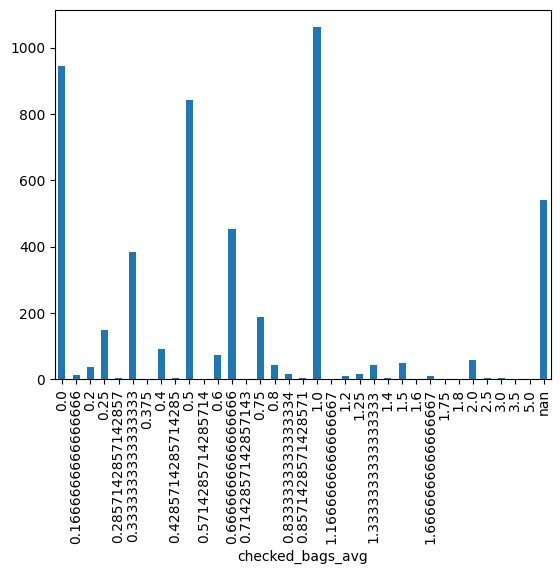

In [26]:
users_features['checked_bags_avg'].value_counts(dropna=False).sort_index().plot(kind='bar')

In [27]:
users_features['bags_per_seat_avg']  = users_features['checked_bags_avg']/ users_features['seats_avg']

In [33]:
users_features['bags_per_seat_avg'].value_counts(dropna=False)

bags_per_seat_avg
 0.000000    944
 1.000000    826
 0.500000    813
-1.000000    541
 0.333333    411
            ... 
 0.714286      1
 0.090909      1
 0.272727      1
 0.111111      1
 1.333333      1
Name: count, Length: 66, dtype: int64

In [30]:
users_features.drop(columns=['checked_bags_avg'],inplace=True)

In [32]:
users_features["bags_per_seat_avg"] = users_features["bags_per_seat_avg"].fillna(-1)

### Cancelation rate

In [35]:
users_features['cancellation_rate']  = users_features['cancellation_rate'].fillna(0)

In [38]:
users_features['unique_flight_destination'] = users_features['unique_flight_destination'].fillna(-1)

### Frequent destination

In [40]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate,bags_per_seat_avg
0,94883,0,1,0,0,1505,54,1.5,2,0.0,2.0,2,1.0,0.250,0.0,0.333333
1,101486,0,1,1,0,1495,53,1.0,2,0.0,1.0,2,0.5,0.250,0.0,0.000000
2,101961,0,1,0,0,1495,45,1.0,5,0.0,5.0,5,1.0,0.625,0.2,0.400000
3,106907,0,1,1,0,1488,47,0.0,1,1.0,1.0,0,inf,0.000,NaN,-1.000000
4,118043,0,0,1,0,1474,53,2.0,5,0.0,3.0,5,0.6,0.625,0.6,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5061,780167,0,1,1,0,1063,51,1.5,2,0.0,2.0,2,1.0,0.250,0.5,0.000000
5062,785186,0,1,1,0,1061,46,1.0,2,0.0,2.0,2,1.0,0.250,0.0,0.000000
5063,792549,0,0,0,0,1058,48,1.0,4,0.0,4.0,4,1.0,0.500,0.0,0.500000
5064,811077,0,1,1,0,1052,47,1.0,1,0.0,1.0,1,1.0,0.125,0.0,0.000000


frequent_destinations is redundant as we have unique_flight_destination and taken_flights. We used it for the user segementation but wont be necessary for the clustering.

In [41]:
users_features.drop(columns = ['frequent_destinations'], inplace=True)

In [42]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,bags_per_seat_avg
0,94883,0,1,0,0,1505,54,1.5,2,0.0,2.0,2,0.250,0.0,0.333333
1,101486,0,1,1,0,1495,53,1.0,2,0.0,1.0,2,0.250,0.0,0.000000
2,101961,0,1,0,0,1495,45,1.0,5,0.0,5.0,5,0.625,0.2,0.400000
3,106907,0,1,1,0,1488,47,0.0,1,1.0,1.0,0,0.000,NaN,-1.000000
4,118043,0,0,1,0,1474,53,2.0,5,0.0,3.0,5,0.625,0.6,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5061,780167,0,1,1,0,1063,51,1.5,2,0.0,2.0,2,0.250,0.5,0.000000
5062,785186,0,1,1,0,1061,46,1.0,2,0.0,2.0,2,0.250,0.0,0.000000
5063,792549,0,0,0,0,1058,48,1.0,4,0.0,4.0,4,0.500,0.0,0.500000
5064,811077,0,1,1,0,1052,47,1.0,1,0.0,1.0,1,0.125,0.0,0.000000


### Discount booking rate

In [44]:
users_features['discount_booking_rate'].value_counts(dropna=False)

discount_booking_rate
0.000000    2073
0.500000     686
0.333333     590
0.250000     384
1.000000     330
NaN          326
0.666667     207
0.200000     187
0.400000     123
0.166667      59
0.750000      46
0.600000      31
0.142857       7
0.285714       6
0.800000       5
0.571429       2
0.714286       1
0.428571       1
0.857143       1
0.125000       1
Name: count, dtype: int64

In [45]:
users_features['discount_booking_rate'] = users_features['discount_booking_rate'].fillna(-1)

In [47]:
users_features.isna().sum()

user_id                      0
gender                       0
married                      0
has_children                 0
home_country                 0
tenure                       0
age                          0
seats_avg                    0
total_trips                  0
cancellation_rate            0
unique_flight_destination    0
taken_flights                0
sessions_booking_rate        0
discount_booking_rate        0
bags_per_seat_avg            0
dtype: int64